In [1]:
# ============================================
# Step 1: Import Libraries and Load Images
# ============================================
# cv2: OpenCV library for image processing (reading, manipulating, stitching images)
# numpy: Numerical computing library for array/matrix operations
# matplotlib.pyplot: Library for displaying images and visualizations

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load two images to create a panorama
# img1 = cv2.imread("R1.jpg")  # Alternative: Load from R1.jpg
# img2 = cv2.imread("R2.jpg")  # Alternative: Load from R2.jpg
# img3 = cv2.imread("R3.jpg")  # Alternative: Load from R3.jpg

# Load images from current directory
img1 = cv2.imread("pano_image1.jpg")  # First image of the panorama
img2 = cv2.imread("pano_image2.jpg")  # Second image of the panorama

In [2]:
# ============================================
# Step 2: Convert Images to Grayscale
# ============================================
# SIFT (Scale-Invariant Feature Transform) works on intensity values, not color
# Grayscale simplifies computation - we only need one channel instead of three (BGR)
# This makes the feature detection faster and more reliable

gray_img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)  # Convert img1 from BGR to grayscale
gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)  # Convert img2 from BGR to grayscale

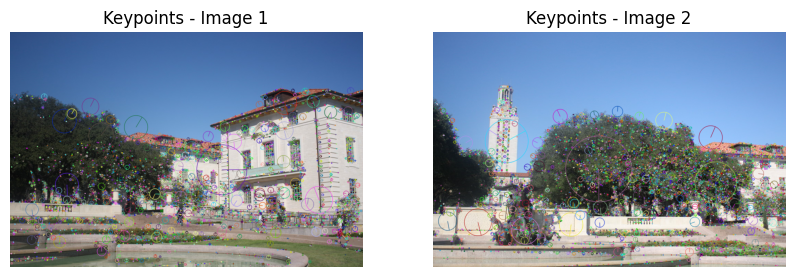

In [3]:
# ============================================
# Step 3: SIFT Keypoint Detection and Visualization
# ============================================
# SIFT (Scale-Invariant Feature Transform) is a feature detection algorithm
# It finds distinctive keypoints in images that are invariant to:
#   - Scale (works at different zoom levels)
#   - Rotation (works regardless of orientation)
#   - Illumination changes (works with different lighting)
#
# Keypoints are found at corners, edges, and blobs - locations with unique patterns
# Each keypoint has a descriptor: a 128-dimensional vector describing the local image region

# Create SIFT detector object
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors for both images
# kp1, kp2: Lists of keypoint objects containing (x, y) location, scale, orientation
# des1, des2: NumPy arrays of shape (N, 128) - descriptors for each keypoint
kp1, des1 = sift.detectAndCompute(gray_img1, None)  # Detect features in image 1
kp2, des2 = sift.detectAndCompute(gray_img2, None)  # Detect features in image 2

# Visualize the detected keypoints by drawing them on the original images
# DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS draws circles indicating keypoint size and orientation
img1_kp_vis = cv2.drawKeypoints(img1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_kp_vis = cv2.drawKeypoints(img2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display both images with their keypoints side by side
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)  # Create a 1x2 subplot, select first cell
plt.imshow(cv2.cvtColor(img1_kp_vis, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for display
plt.title("Keypoints - Image 1")
plt.axis("off")  # Hide axis ticks

plt.subplot(1, 2, 2)  # Select second cell
plt.imshow(cv2.cvtColor(img2_kp_vis, cv2.COLOR_BGR2RGB))
plt.title("Keypoints - Image 2")
plt.axis("off")

plt.show()  # Render the figure

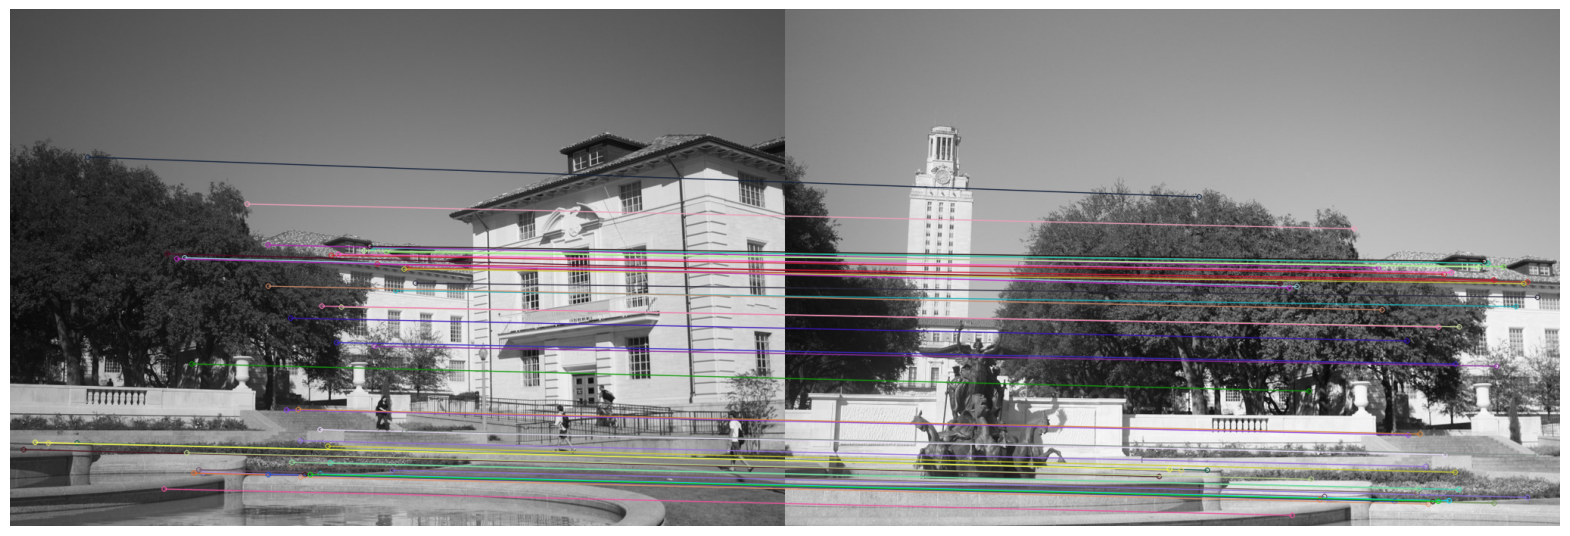

Number of good matches: 50


In [4]:
# ============================================
# Step 4: Find Matching Points Between Images
# ============================================
# This function finds corresponding points between two images using SIFT features
# and the Lowe's ratio test to filter out ambiguous matches.
#
# Parameters:
#   src_img: Source image (we want to find where its features match in target)
#   target_img: Target image (the image we're matching against)
#   threshold: Ratio threshold for Lowe's test (lower = stricter, typically 0.7)
#   show_img: Whether to display visualization of matches
#   max_matches: Maximum number of matches to return
#
# Returns:
#   src_pts: Array of (x, y) coordinates in source image
#   dst_pts: Array of (x, y) coordinates in target image (corresponding points)

def get_correspondences(src_img, target_img, threshold, show_img=False, max_matches=50):
    # Create SIFT detector to find keypoints and descriptors
    sift = cv2.SIFT_create()
    
    # Detect keypoints and compute descriptors for both images
    # Keypoints: locations (x, y), scale, orientation
    # Descriptors: 128-dimensional vectors describing each keypoint's local region
    src_img_kp, src_img_desc = sift.detectAndCompute(src_img, None)
    target_img_kp, target_img_desc = sift.detectAndCompute(target_img, None)
    
    # Create Brute-Force matcher to find correspondences
    # BFMatcher compares descriptors using Euclidean distance
    bf = cv2.BFMatcher()
    
    # K-Nearest Neighbors matching with k=2
    # For each descriptor in source, find 2 closest descriptors in target
    # This gives us the best match (a) and second-best match (b)
    matches = bf.knnMatch(src_img_desc, target_img_desc, k=2)
    
    # Apply Lowe's ratio test to filter good matches
    # A match is considered good only if the best match is significantly
    # better than the second-best match (by at least 'threshold' factor)
    # This eliminates ambiguous matches where a point could match multiple places
    good_matches = []
    for a, b in matches:  # a = best match, b = second-best match
        if a.distance <= b.distance * threshold:  # If best is sufficiently better than second
            good_matches.append(a)
    
    # Sort matches by distance (lower distance = better match)
    good_matches = sorted(good_matches, key=lambda x: x.distance)
    # Limit to maximum number of matches
    good_matches = good_matches[:max_matches]
    
    # Optionally display visualization of matches
    if show_img:
        # Draw lines connecting matching keypoints between the two images
        img_matches = cv2.drawMatches(
            src_img, src_img_kp,      # Source image and its keypoints
            target_img, target_img_kp, # Target image and its keypoints
            good_matches,              # List of good matches to draw
            None,                      # No output image (create new)
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS  # Don't draw unmatched keypoints
        )
        plt.figure(figsize=(20, 10))
        plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    
    # Extract coordinates of matched points
    # m.queryIdx: index of keypoint in source image
    # m.trainIdx: index of keypoint in target image
    # .pt: (x, y) coordinate of the keypoint
    src_pts = np.float32([src_img_kp[m.queryIdx].pt for m in good_matches])
    dst_pts = np.float32([target_img_kp[m.trainIdx].pt for m in good_matches])
    
    print(f'Number of good matches: {len(good_matches)}')
    return src_pts, dst_pts

# Find correspondences between the two grayscale images
# Using threshold=0.7 (standard for Lowe's ratio test)
src_pts, dst_pts = get_correspondences(
    gray_img1,   # Source: first image
    gray_img2,   # Target: second image
    0.7,         # Ratio threshold (0.7 is standard - lower = stricter)
    True         # Show visualization
)

In [5]:
# ============================================
# Step 5: Compute Homography Matrix (Manual Implementation)
# ============================================
# Homography is a 3x3 transformation matrix that maps points from one image
# to their corresponding positions in another image. It represents:
#   - Rotation, translation, scaling, and perspective changes
#
# The homography matrix H has 9 elements, but only 8 are independent (last element = 1)
# Therefore, we need at least 4 point correspondences to solve for H (4 x 2 = 8 equations)
#
# We use the Direct Linear Transform (DLT) algorithm:
# 1. Build a system of linear equations from point correspondences
# 2. Solve using Singular Value Decomposition (SVD)
#
# Parameters:
#   src_pts: Source points (coordinates in first image)
#   dst_pts: Destination points (coordinates in second image)
#
# Returns:
#   H: 3x3 homography matrix

def compute_homography_parameters(src_pts, dst_pts):
    # Validate inputs: both point arrays must have same length
    assert len(src_pts) == len(dst_pts)
    # Need at least 4 points to compute homography (8 DOF)
    assert len(src_pts) >= 4
    
    # Build the measurement matrix A for the DLT algorithm
    # Each point correspondence contributes 2 rows to matrix A
    # The equation: Ah = 0, where h is the homography vector (9 elements)
    A = []
    for i in range(len(src_pts)):
        x, y = src_pts[i]      # Source point coordinates
        x_p, y_p = dst_pts[i]  # Destination point coordinates
        
        # Two equations per point pair (from homography: x' = (ax + by + c)/(gx + hy + 1))
        # Row 1: -x, -y, -1, 0, 0, 0, x*x', y*x', x'
        A.append([-x, -y, -1, 0, 0, 0, x*x_p, y*x_p, x_p])
        # Row 2: 0, 0, 0, -x, -y, -1, x*y', y*y', y'
        A.append([0, 0, 0, -x, -y, -1, x*y_p, y*y_p, y_p])
    
    # Convert to NumPy array: shape is (2N x 9) where N = number of point pairs
    A = np.array(A)
    
    # Solve using Singular Value Decomposition (SVD)
    # SVD decomposes A = U * S * V^T
    # The solution h is the right singular vector corresponding to smallest singular value
    # This gives us the "best fit" homography that minimizes ||Ah||
    U, S, Vt = np.linalg.svd(A)
    
    # The last row of Vt (Vt[-1]) corresponds to the smallest singular value
    # This is our homography vector
    H = Vt[-1, :]
    
    # Normalize so that H[2,2] = 1 (enforce the scale)
    H = H / H[-1]
    
    # Reshape from 1D vector (9 elements) to 3x3 matrix
    H = H.reshape((3, 3))
    
    return H

In [6]:
# ============================================
# Step 6: Compute and Invert Homography Matrix
# ============================================
# Compute the homography matrix that transforms points from img1 to img2
# Also compute its inverse for the reverse transformation (img2 to img1)

H = compute_homography_parameters(src_pts, dst_pts)  # Compute 3x3 homography matrix
H_inv = np.linalg.inv(H)  # Compute inverse for backward mapping

In [7]:
# ============================================
# Step 7: Calculate Output Canvas Size
# ============================================
# To create a panorama, we need to determine the size of the output canvas
# that can contain both images after warping. We do this by:
# 1. Getting the corners of both images
# 2. Warping img1's corners using the homography
# 3. Finding the bounding box that contains all corners

# Get dimensions of both images
# img.shape returns (height, width, channels) - we only need height and width
h1, w1 = img1.shape[:2]  # Height and width of image 1
h2, w2 = img2.shape[:2]  # Height and width of image 2

# Define the four corners of img1 in pixel coordinates
# Order: top-left, top-right, bottom-right, bottom-left
corners_img1 = np.array([
    [0, 0],      # Top-left corner
    [w1, 0],     # Top-right corner
    [w1, h1],    # Bottom-right corner
    [0, h1]      # Bottom-left corner
], dtype=np.float32)

# Convert corners to homogeneous coordinates (add 1 as third coordinate)
# Homogeneous coordinates allow us to represent translation as matrix multiplication
corners_img1_h = np.hstack([corners_img1, np.ones((4, 1))])  # Shape: (4, 3)

# Transform img1 corners using the homography matrix
# H @ corners.T performs the perspective transformation
# Each corner becomes: [x', y', w'] where x' = x/w, y' = y/w
warped_corners = (H @ corners_img1_h.T).T  # Transform corners

# Convert back from homogeneous coordinates (divide by third coordinate)
warped_corners = warped_corners[:, :2] / warped_corners[:, 2:]

# Combine warped corners of img1 with the corners of img2
# This gives us all corner points that must fit in the output canvas
all_corners = np.vstack((
    warped_corners,                    # Warped corners of img1
    [[0,0], [w2,0], [w2,h2], [0,h2]]  # Original corners of img2
))

# Find the bounding box that contains all corners
# This determines the minimum canvas size needed
x_min, y_min = np.int32(all_corners.min(axis=0))  # Minimum x and y coordinates
x_max, y_max = np.int32(all_corners.max(axis=0))  # Maximum x and y coordinates

In [8]:
# ============================================
# Step 8: Create Output Canvas
# ============================================
# Create an empty canvas (black image) large enough to hold the panorama
# The canvas size is determined by the bounding box of all transformed corners

# Calculate required dimensions
output_width = x_max - x_min   # Total width needed
output_height = y_max - y_min  # Total height needed

# Create empty canvas with 3 color channels (BGR), initialized to black (0)
# dtype=np.uint8: 8-bit unsigned integers (0-255 range for pixel values)
output = np.zeros((output_height, output_width, 3), dtype=np.uint8)

In [9]:
# ============================================
# Step 9: Create Translation Matrix
# ============================================
# The warped image might have negative coordinates after transformation.
# We need to shift everything to positive coordinates that fit in our canvas.
# This translation moves the entire warped image so its top-left corner is at (0,0).

# Create translation matrix to shift image
# This is a 3x3 affine transformation matrix:
# [1 0 -x_min]  →  x' = x - x_min
# [0 1 -y_min]  →  y' = y - y_min
# [0 0 1    ]   →  w' = w (homogeneous coordinate unchanged)
translation = np.array([
    [1, 0, -x_min],  # Shift x by -x_min
    [0, 1, -y_min],  # Shift y by -y_min
    [0, 0, 1]        # Keep homogeneous coordinate
])

# Combine translation with homography: apply homography THEN translate
H_total = translation @ H           # Combined transformation matrix
H_total_inv = np.linalg.inv(H_total)  # Inverse for backward mapping

In [10]:
# ============================================
# Step 10: Warp Image 1 onto Output Canvas (Inverse Mapping)
# ============================================
# We use inverse mapping: for each pixel in the OUTPUT canvas, we find
# which pixel from the SOURCE image should be placed there.
#
# This is more accurate than forward mapping because it avoids holes/gaps
# in the output image.
#
# We also use bilinear interpolation for smooth pixel values instead of
# rounding to nearest neighbor (which creates jagged edges).

# Iterate over every pixel in the output canvas
for y in range(output_height):
    for x in range(output_width):
        
        # Create homogeneous coordinate for current output pixel
        pt = np.array([x, y, 1])
        
        # Transform from output coordinates to source image coordinates
        # Using inverse homography: where in img1 does this output pixel come from?
        src_pt = H_total_inv @ pt
        
        # Convert from homogeneous coordinates back to Cartesian
        # (divide by the third coordinate)
        src_pt /= src_pt[2]
        
        # Get the source pixel coordinates
        sx, sy = src_pt[0], src_pt[1]
        
        # Check if the source point is within img1's bounds
        # We need -1 buffer because we'll access img1[y0+1, x0+1] for interpolation
        if 0 <= sx < w1-1 and 0 <= sy < h1-1:
            
            # Bilinear Interpolation:
            # Instead of rounding to nearest pixel, we interpolate between
            # the 4 nearest pixels for smoother results
            
            # Get integer and fractional parts
            x0, y0 = int(sx), int(sy)    # Integer coordinates (top-left pixel)
            dx, dy = sx - x0, sy - y0    # Fractional parts (0 to 1)
            
            # Compute weighted average of 4 neighboring pixels:
            # (1-dx)*(1-dy) * top-left     + dx*(1-dy) * top-right
            # (1-dx)*dy     * bottom-left  + dx*dy     * bottom-right
            val = (1-dx)*(1-dy)*img1[y0, x0] + \
                  dx*(1-dy)*img1[y0, x0+1] + \
                  (1-dx)*dy*img1[y0+1, x0] + \
                  dx*dy*img1[y0+1, x0+1]
            
            # Assign the interpolated color value to output pixel
            output[y, x] = val

In [ ]:
# ============================================
# Step 11: Place Image 2 onto Output Canvas
# ============================================
# Place the second image onto the canvas at the correct position.
# The translation (x_min, y_min) tells us where img2 should be placed
# relative to the canvas origin.

# Place img2 first (as the base/background)
# Slice notation: output[y_start:y_end, x_start:x_end] = img2
# -y_min: shift up if y_min is negative
# h2 - y_min: height of img2 portion to place
output[-y_min:h2 - y_min, -x_min:w2 - x_min] = img2
# then warp img1 (only overwrite valid pixels)
if 0 <= sx < w1-1 and 0 <= sy < h1-1:
    output[y, x] = val
# Note: The warped img1 pixels from the previous step already exist in 'output'
# This step overlays img2 on top - where both images exist, img2 will be visible
# (simple overwrite blending - more advanced methods like alpha blending exist)

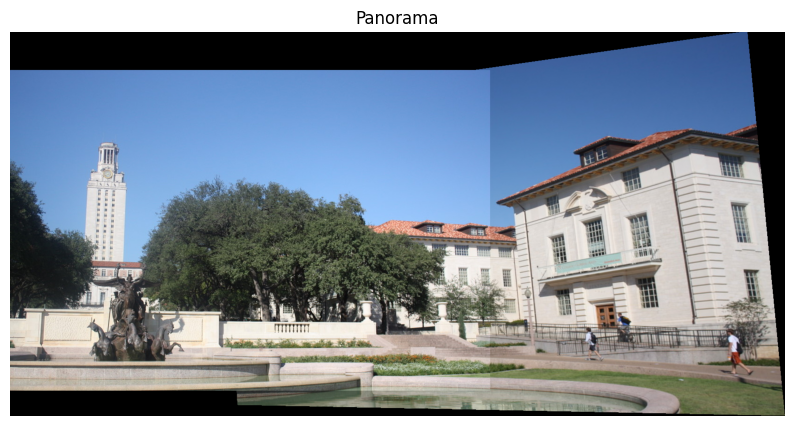

In [12]:
# ============================================
# Step 12: Display the Panorama Result
# ============================================
# Convert from BGR (OpenCV default) to RGB (matplotlib display format)
# and show the final stitched panorama

plt.figure(figsize=(10,5))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))  # Convert BGR → RGB for display
plt.axis('off')  # Hide axis ticks and labels
plt.title("Panorama")  # Add title
plt.show()  # Render the figure

In [13]:
# ============================================
# BONUS: Stitch a 3rd Image
# ============================================
# This section extends the panorama by adding a third image.
# The process is similar to the two-image case:
# 1. Use the existing panorama as the base
# 2. Find correspondences between img3 and the panorama
# 3. Compute homography to warp img3
# 4. Create a larger canvas and blend all images

# Load third image
gray_img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

# Step 1: Use your RESULT as base (panorama)
base_panorama = output.copy()
gray_base = cv2.cvtColor(base_panorama, cv2.COLOR_BGR2GRAY)

# Step 2: Find correspondences (img3 → panorama)
src_pts_3, dst_pts_3 = get_correspondences(
    gray_img3,
    gray_base,
    0.7,
    show_img=True
)

# Step 3: Compute Homography
H_3 = compute_homography_parameters(src_pts_3, dst_pts_3)

# Step 4: Compute new canvas dimensions
h3, w3 = img3.shape[:2]
h_base, w_base = base_panorama.shape[:2]

# Define corners of img3
corners_img3 = np.array([
    [0, 0],
    [w3, 0],
    [w3, h3],
    [0, h3]
], dtype=np.float32)

# Convert to homogeneous coordinates
corners_img3_h = np.hstack([corners_img3, np.ones((4, 1))])

# Warp corners using homography
warped_corners3 = (H_3 @ corners_img3_h.T).T
warped_corners3 = warped_corners3[:, :2] / warped_corners3[:, 2:]

# Combine with base panorama corners
all_corners = np.vstack((
    warped_corners3,
    [[0,0], [w_base,0], [w_base,h_base], [0,h_base]]
))

# Find new bounding box
x_min, y_min = np.int32(all_corners.min(axis=0))
x_max, y_max = np.int32(all_corners.max(axis=0))

new_w = x_max - x_min
new_h = y_max - y_min

# Step 5: Create translation matrix
T = np.array([
    [1, 0, -x_min],
    [0, 1, -y_min],
    [0, 0, 1]
])

H_total_3 = T @ H_3
H_total_3_inv = np.linalg.inv(H_total_3)

# Step 6: Warp img3 onto new canvas
result_3 = np.zeros((new_h, new_w, 3), dtype=np.uint8)

for y in range(new_h):
    for x in range(new_w):
        
        pt = np.array([x, y, 1])
        src = H_total_3_inv @ pt
        src /= src[2]
        
        sx, sy = src[0], src[1]
        
        if 0 <= sx < w3-1 and 0 <= sy < h3-1:
            
            # Bilinear interpolation
            x0, y0 = int(sx), int(sy)
            dx, dy = sx - x0, sy - y0
            
            val = (1-dx)*(1-dy)*img3[y0, x0] + \
                  dx*(1-dy)*img3[y0, x0+1] + \
                  (1-dx)*dy*img3[y0+1, x0] + \
                  dx*dy*img3[y0+1, x0+1]
            
            result_3[y, x] = val

# Step 7: Place old panorama onto new canvas
result_3[-y_min:h_base - y_min, -x_min:w_base - x_min] = base_panorama

# Step 8: Simple blend (overwrite)
for y in range(new_h):
    for x in range(new_w):
        
        if np.any(result_3[y, x] > 0):
            continue  # keep existing pixel

# Step 9: Show final result
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(result_3, cv2.COLOR_BGR2RGB))
plt.title("Final Panorama (3 Images)")
plt.axis("off")
plt.show()

NameError: name 'img3' is not defined

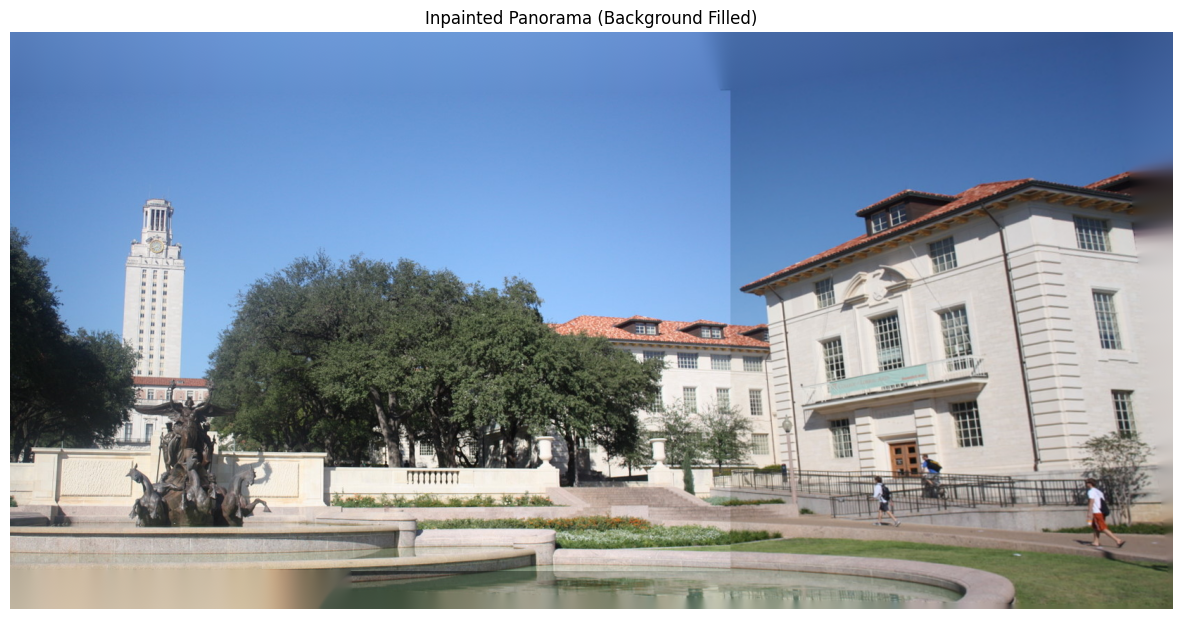

In [14]:

# Sometimes the panorama has black/missing regions where no image data exists.
# We can use OpenCV's inpainting algorithm to fill these gaps.
#
# How inpainting works:
# 1. Create a mask of the missing (black) pixels
# 2. For each missing pixel, look at neighboring pixels
# 3. Fill in the pixel based on a weighted average of neighbors
#
# Two algorithms available:
#   - cv2.INPAINT_TELEA: Uses fast marching method (generally faster)
#   - cv2.INPAINT_NS: Uses Navier-Stokes based method

# 1. Convert to grayscale to identify black pixels
gray_pano = cv2.cvtColor(output, cv2.COLOR_BGR2GRAY)

# 2. Create an INVERTED mask: Black pixels (0) become white (255), others become black (0)
# THRESH_BINARY_INV inverts the threshold result
# Threshold of 1 means: pixels < 1 become white (255), pixels >= 1 become black (0)
# This effectively marks all dark/missing regions as "to be inpainted"
_, mask = cv2.threshold(gray_pano, 1, 255, cv2.THRESH_BINARY_INV)

# 3. Dilate the mask slightly to catch boundary artifacts
# This ensures the algorithm pulls colors from just inside the good image,
# not the dark edge itself
kernel = np.ones((5, 5), np.uint8)  # 5x5 square kernel
mask = cv2.dilate(mask, kernel, iterations=1)  # Expand the mask by 1 pixel

# 4. Inpaint the missing regions
# inpaintRadius: How far to look for neighboring pixels (in pixels)
# flags: The algorithm to use
#   - cv2.INPAINT_TELEA: Fast marching method (usually produces smoother results)
#   - cv2.INPAINT_NS: Navier-Stokes based method
inpainted_panorama = cv2.inpaint(output, mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

# Display the inpainted result
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(inpainted_panorama, cv2.COLOR_BGR2RGB))
plt.title("Inpainted Panorama (Background Filled)")
plt.axis("off")
plt.show()

In [15]:
def forward_warp(img, H_matrix, output_width, output_height):
    """
    Implements manual forward warping from source image to a new canvas.
    """
    h, w = img.shape[:2]
    # Create an empty canvas
    warped_img = np.zeros((output_height, output_width, 3), dtype=np.uint8)
    
    # Iterate over every pixel in the SOURCE image
    for y in range(h):
        for x in range(w):
            # 1. Create homogeneous coordinate [x, y, 1]
            p = np.array([x, y, 1])
            
            # 2. Apply homography transformation (H * p)
            p_prime = H_matrix @ p
            
            # 3. Convert back from homogeneous (divide by w)
            p_prime = p_prime / p_prime[2]
            
            # 4. Round to nearest integer to find destination pixel
            new_x = int(np.round(p_prime[0]))
            new_y = int(np.round(p_prime[1]))
            
            # 5. If the new coordinate is inside our canvas bounds, assign the color
            if 0 <= new_x < output_width and 0 <= new_y < output_height:
                warped_img[new_y, new_x] = img[y, x]
                
    return warped_img

# To test or use it in your code, you would call it like this:
# forward_result = forward_warp(img1, H_total, output_width, output_height)
